# Stage 6 – Event Aggregation

Collapses consecutive flagged hours per building into discrete anomaly **events**.

Input : `stage4b_anomalies.parquet` (hourly flags, 2,031,624 rows)
Output: `stage6_events.parquet` (one row per event)

Each event carries: start/end timestamps, duration, peak z-score, mean z-score,
dominant direction, peak severity, and building metadata.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

OUTPUTS_DIR      = Path('../../data/processed/anomaly-detection')
ANOMALIES_PATH   = OUTPUTS_DIR / 'stage4b_anomalies.parquet'
EVENTS_OUT       = OUTPUTS_DIR / 'stage6_events.parquet'

# Two consecutive flagged blocks separated by <= GAP_TOLERANCE_H non-flagged hours
# are merged into a single event. Set to 0 for strict-consecutive only.
GAP_TOLERANCE_H  = 1

SEV_RANK = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1, 'normal': 0}

In [2]:
scored = pd.read_parquet(ANOMALIES_PATH)
scored['timestamp'] = pd.to_datetime(scored['timestamp'])
scored['building_id'] = scored['building_id'].astype(str)
scored = scored.sort_values(['building_id', 'timestamp']).reset_index(drop=True)

print(f'Rows      : {len(scored):,}')
print(f'Buildings : {scored["building_id"].nunique():,}')
print(f'Flagged   : {scored["is_anomaly"].sum():,}  ({scored["is_anomaly"].mean():.2%})')
print(f'Period    : {scored["timestamp"].min()} → {scored["timestamp"].max()}')

Rows      : 2,031,624
Buildings : 1,439
Flagged   : 124,606  (6.13%)
Period    : 2017-11-01 00:00:00 → 2017-12-31 23:00:00


---
## 1. Event Identification

In [3]:
# Step 1: dilate is_anomaly by GAP_TOLERANCE_H so nearby flagged blocks merge.
# A row is 'in-event' if it or any of the next GAP_TOLERANCE_H rows is flagged.
if GAP_TOLERANCE_H > 0:
    flag_col = scored['is_anomaly'].copy()
    for shift in range(1, GAP_TOLERANCE_H + 1):
        # only dilate within the same building
        shifted = (
            scored.groupby('building_id')['is_anomaly']
            .shift(-shift, fill_value=False)
        )
        flag_col = flag_col | shifted
    scored['_in_event'] = flag_col
else:
    scored['_in_event'] = scored['is_anomaly']

# Step 2: mark the start of each new event run per building.
prev_in_event = scored.groupby('building_id')['_in_event'].shift(1, fill_value=False)
scored['_new_event'] = scored['_in_event'] & ~prev_in_event
scored['_event_id']  = scored['_new_event'].cumsum()
scored['_event_id']  = scored['_event_id'].where(scored['_in_event'], other=pd.NA)

n_raw_events = scored['_new_event'].sum()
print(f'Raw event blocks (after gap={GAP_TOLERANCE_H}h merge): {n_raw_events:,}')

Raw event blocks (after gap=1h merge): 67,528


---
## 2. Event Aggregation

In [4]:
# Aggregate only the actually-flagged rows within each event block.
flagged = scored[scored['is_anomaly']].copy()

events = (
    flagged
    .groupby(['building_id', '_event_id'], sort=False)
    .agg(
        event_start        = ('timestamp',     'min'),
        event_end          = ('timestamp',     'max'),
        n_flagged_h        = ('is_anomaly',    'sum'),
        peak_z             = ('anomaly_score', 'max'),
        mean_z             = ('anomaly_score', 'mean'),
        peak_severity      = ('severity',      lambda s: max(s, key=lambda x: SEV_RANK.get(x, 0))),
        dominant_direction = ('direction',     lambda s: s.value_counts().index[0]),
        site_id            = ('site_id',       'first'),
        primaryspaceusage  = ('primaryspaceusage', 'first'),
        sqm                = ('sqm',           'first'),
    )
    .reset_index()
    .drop(columns=['_event_id'])
)

events['duration_h'] = (
    (events['event_end'] - events['event_start']).dt.total_seconds() / 3600 + 1
).astype(int)
events['mean_z'] = events['mean_z'].round(3)
events['peak_z'] = events['peak_z'].round(3)

# Re-order columns
col_order = [
    'building_id', 'site_id', 'primaryspaceusage', 'sqm',
    'event_start', 'event_end', 'duration_h', 'n_flagged_h',
    'peak_z', 'mean_z', 'peak_severity', 'dominant_direction',
]
events = events[[c for c in col_order if c in events.columns]]

print(f'Total events  : {len(events):,}')
print(f'Buildings     : {events["building_id"].nunique():,}')
print(f'Avg events/bld: {len(events) / events["building_id"].nunique():.1f}')
display(events.head(10))

Total events  : 67,528
Buildings     : 1,408
Avg events/bld: 48.0


,building_id,site_id,primaryspaceusage,sqm,event_start,event_end,duration_h,n_flagged_h,peak_z,mean_z,peak_severity,dominant_direction
0,Bear_assembly_Angel,Bear,Entertainment/public assembly,22117.0,2017-11-01 17:00:00,2017-11-01 20:00:00,4,3,6.947,5.759,High,over
1,Bear_assembly_Angel,Bear,Entertainment/public assembly,22117.0,2017-11-02 17:00:00,2017-11-02 20:00:00,4,3,9.192,5.576,High,over
2,Bear_assembly_Angel,Bear,Entertainment/public assembly,22117.0,2017-11-03 17:00:00,2017-11-03 17:00:00,1,1,8.588,8.588,High,over
3,Bear_assembly_Angel,Bear,Entertainment/public assembly,22117.0,2017-11-03 20:00:00,2017-11-03 20:00:00,1,1,6.404,6.404,High,under
4,Bear_assembly_Angel,Bear,Entertainment/public assembly,22117.0,2017-11-06 06:00:00,2017-11-06 06:00:00,1,1,3.397,3.397,Low,over
5,Bear_assembly_Angel,Bear,Entertainment/public assembly,22117.0,2017-11-06 18:00:00,2017-11-06 19:00:00,2,2,5.665,4.685,Medium,over
6,Bear_assembly_Angel,Bear,Entertainment/public assembly,22117.0,2017-11-06 22:00:00,2017-11-06 22:00:00,1,1,6.494,6.494,High,under
7,Bear_assembly_Angel,Bear,Entertainment/public assembly,22117.0,2017-11-07 16:00:00,2017-11-07 19:00:00,4,3,5.631,4.780,Medium,over
8,Bear_assembly_Angel,Bear,Entertainment/public assembly,22117.0,2017-11-08 17:00:00,2017-11-08 20:00:00,4,3,5.856,4.654,Medium,over
9,Bear_assembly_Angel,Bear,Entertainment/public assembly,22117.0,2017-11-09 16:00:00,2017-11-09 19:00:00,4,3,5.700,4.832,Medium,over


---
## 3. Results

=== Event-level summary ===
       duration_h  n_flagged_h    peak_z    mean_z
count    67528.00     67528.00  67528.00  67528.00
mean         2.23         1.85      5.85      4.97
std          5.07         2.24      6.39      3.33
min          1.00         1.00      3.00      3.00
25%          1.00         1.00      3.49      3.45
50%          1.00         1.00      4.27      4.08
75%          2.00         2.00      5.92      5.28
max        464.00       103.00    305.39    152.74

Severity breakdown:
  Critical: 5,792  (8.6%)
  High    : 10,684  (15.8%)
  Medium  : 22,000  (32.6%)
  Low     : 29,052  (43.0%)

Direction breakdown:
  over    : 39,113  (57.9%)
  under   : 28,415  (42.1%)


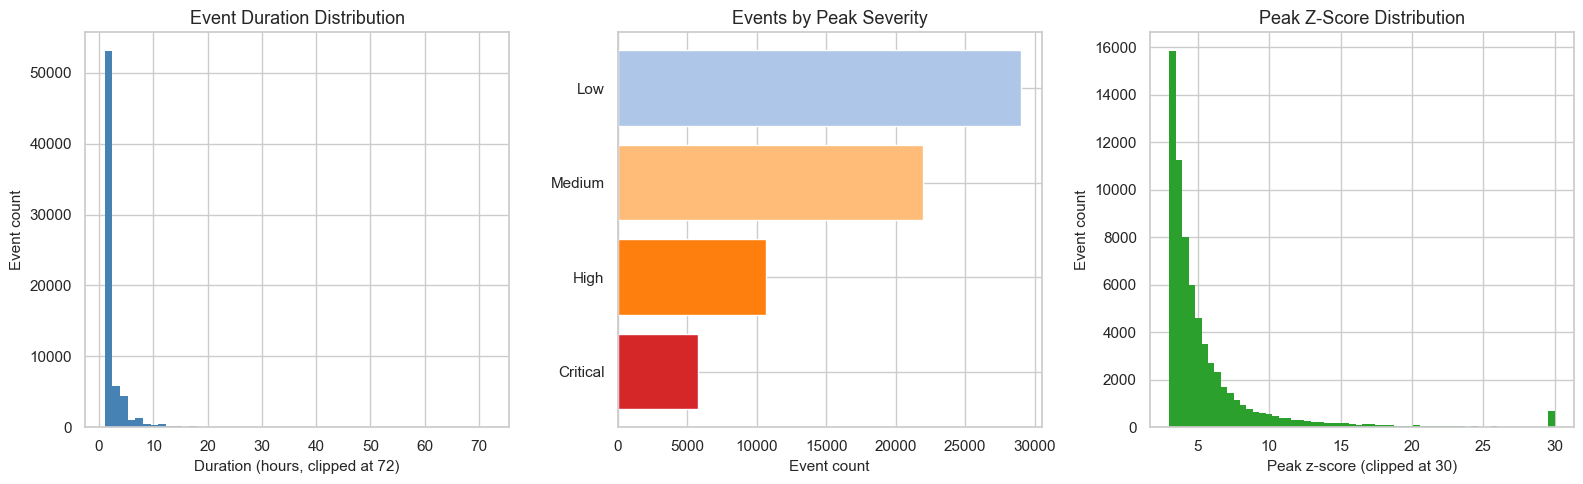

In [5]:
print('=== Event-level summary ===')
print(events[['duration_h', 'n_flagged_h', 'peak_z', 'mean_z']].describe().round(2))

sev_order = ['Critical', 'High', 'Medium', 'Low']
sev_counts = events['peak_severity'].value_counts().reindex(sev_order).fillna(0).astype(int)
dir_counts = events['dominant_direction'].value_counts()

print('\nSeverity breakdown:')
for sev, cnt in sev_counts.items():
    print(f'  {sev:8s}: {cnt:,}  ({cnt / len(events):.1%})')

print('\nDirection breakdown:')
for d, cnt in dir_counts.items():
    print(f'  {d:8s}: {cnt:,}  ({cnt / len(events):.1%})')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Duration distribution
dur_clip = events['duration_h'].clip(upper=72)
axes[0].hist(dur_clip, bins=50, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Duration (hours, clipped at 72)')
axes[0].set_ylabel('Event count')
axes[0].set_title('Event Duration Distribution')

# Severity breakdown
colors_sev = ['#d62728', '#ff7f0e', '#ffbb78', '#aec7e8']
axes[1].barh(sev_counts.index, sev_counts.values, color=colors_sev)
axes[1].set_xlabel('Event count')
axes[1].set_title('Events by Peak Severity')

# Peak-z distribution
pz_clip = events['peak_z'].clip(upper=30)
axes[2].hist(pz_clip, bins=60, color='#2ca02c', edgecolor='none')
axes[2].set_xlabel('Peak z-score (clipped at 30)')
axes[2].set_ylabel('Event count')
axes[2].set_title('Peak Z-Score Distribution')

plt.tight_layout()
plt.show()

In [6]:
bld_rank = (
    events
    .groupby(['building_id', 'site_id', 'primaryspaceusage'])
    .agg(
        total_events    = ('event_start',      'count'),
        n_critical      = ('peak_severity',    lambda s: (s == 'Critical').sum()),
        n_high          = ('peak_severity',    lambda s: (s == 'High').sum()),
        total_flagged_h = ('n_flagged_h',      'sum'),
        max_peak_z      = ('peak_z',           'max'),
        median_duration = ('duration_h',       'median'),
    )
    .reset_index()
    .sort_values(['n_critical', 'total_events', 'max_peak_z'], ascending=False)
    .reset_index(drop=True)
)

print('Top 20 buildings by event severity:')
display(bld_rank.head(20))

Top 20 buildings by event severity:


,building_id,site_id,primaryspaceusage,total_events,n_critical,n_high,total_flagged_h,max_peak_z,median_duration
0,Rat_assembly_Aubrey,Rat,Entertainment/public assembly,122,122.0,0.0,134,18.530,1.0
1,Cockatoo_assembly_Valencia,Cockatoo,Entertainment/public assembly,173,84.0,38.0,695,16.078,3.0
2,Rat_assembly_Jannie,Rat,Entertainment/public assembly,108,84.0,0.0,593,62.002,5.0
3,Hog_warehouse_Porsha,Hog,Warehouse/storage,136,83.0,35.0,182,24.325,1.0
4,Panther_parking_Asia,Panther,Parking,125,82.0,42.0,219,18.749,2.0
5,Panther_parking_Alaina,Panther,Parking,121,73.0,43.0,136,19.569,1.0
6,Rat_assembly_Lillie,Rat,Entertainment/public assembly,150,63.0,21.0,342,31.629,2.0
7,Panther_parking_Stanley,Panther,Parking,125,59.0,56.0,158,16.680,1.0
8,Lamb_office_Caitlin,Lamb,Office,129,55.0,28.0,482,21.968,3.0
9,Rat_public_Vickie,Rat,Public services,115,53.0,37.0,642,75.388,5.0


---
## 4. Export

In [7]:
events.to_parquet(EVENTS_OUT, index=False)
print(f'Events saved → {EVENTS_OUT}')
print(f'Rows         : {len(events):,}')
print(f'Columns      : {list(events.columns)}')

Events saved → ..\..\data\processed\anomaly-detection\stage6_events.parquet
Rows         : 67,528
Columns      : ['building_id', 'site_id', 'primaryspaceusage', 'sqm', 'event_start', 'event_end', 'duration_h', 'n_flagged_h', 'peak_z', 'mean_z', 'peak_severity', 'dominant_direction']
